In [51]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
import nltk

FILE_PATH = "/content/youtube_phase2_cleaned.csv"

df = pd.read_csv(FILE_PATH)



print("\nDataset Shape:")
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")

print("\nFirst 5 Rows of the Dataset:")
display(df.head(5))


Dataset Shape:
Rows: 3781 | Columns: 11

First 5 Rows of the Dataset:


,kind,commentId,videoId,publishedAt,updatedAt,textDisplay,likeCount,text_clean,publishedAt_dt,updatedAt_dt,text_processed
0,youtube#comment,Ugz3TjxB2c5U0i01kht4AaABAg,Z2UqlSo3G-A,2026-02-11T18:29:35Z,2026-02-11T18:29:35Z,Crazy.,0,Crazy.,2026-02-11 18:29:35+00:00,2026-02-11 18:29:35+00:00,crazy
1,youtube#comment,Ugz3M8msHzpXu3-VZsJ4AaABAg,Z2UqlSo3G-A,2026-02-11T18:27:52Z,2026-02-11T18:27:52Z,They aren't going to let us have this vaccine....,0,They aren't going to let us have this vaccine....,2026-02-11 18:27:52+00:00,2026-02-11 18:27:52+00:00,be not go let vaccine vaccine ffs mrna vaccine...
2,youtube#comment,UgwQPhsmvJ6RkrehQ1V4AaABAg,Z2UqlSo3G-A,2026-02-11T18:27:09Z,2026-02-11T18:27:09Z,Well...the rich will get vaccinated abroad if ...,0,Well...the rich will get vaccinated abroad if ...,2026-02-11 18:27:09+00:00,2026-02-11 18:27:09+00:00,wellthe rich get vaccinate abroad good
3,youtube#comment,UgxjwrOXJBWY8E1K-Fp4AaABAg,Z2UqlSo3G-A,2026-02-11T18:23:59Z,2026-02-11T18:23:59Z,I think I may have to get my vaccines in Canad...,0,I think I may have to get my vaccines in Canad...,2026-02-11 18:23:59+00:00,2026-02-11 18:23:59+00:00,think may get vaccine move
4,youtube#comment,UgySblFtCIhn_kccex14AaABAg,Z2UqlSo3G-A,2026-02-11T18:21:21Z,2026-02-11T18:21:21Z,"So, Americans over 50 may have to get vaccinat...",0,"So, Americans over 50 may have to get vaccinat...",2026-02-11 18:21:21+00:00,2026-02-11 18:21:21+00:00,americans may get vaccinate covid outside fda ...


In [ ]:
TEXT_COL = "text_clean"

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate comments:")
print(df.duplicated(subset=[TEXT_COL]).sum())

Missing values:
kind              0
commentId         0
videoId           0
publishedAt       0
updatedAt         0
textDisplay       0
likeCount         0
text_clean        0
publishedAt_dt    0
updatedAt_dt      0
text_processed    0
dtype: int64

Duplicate comments:
17


In [ ]:
#  Identify columns

TEXT_COL = "text_clean"
DATE_COL = "publishedAt_dt"


if TEXT_COL not in df.columns:
    for c in df.columns:
        if "text" in c.lower() or "comment" in c.lower():
            TEXT_COL = c
            break

if DATE_COL not in df.columns:
    for c in df.columns:
        if "published" in c.lower() or "date" in c.lower() or "time" in c.lower():
            DATE_COL = c
            break

print("\n Using TEXT_COL =", TEXT_COL)
print(" Using DATE_COL =", DATE_COL)



 Using TEXT_COL = text_clean
 Using DATE_COL = publishedAt_dt


In [ ]:

num_comments = len(df)
print(" Number of comments:", num_comments)

 Number of comments: 3781


/tmp/ipykernel_535/2044726397.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.dropna(subset=[DATE_COL]).set_index(DATE_COL).resample("M").size()


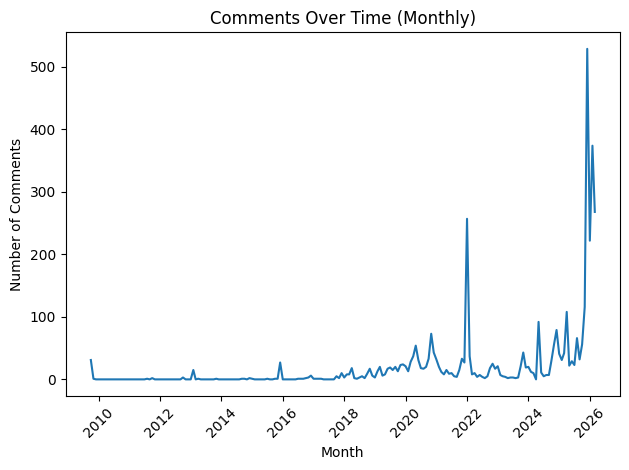

In [ ]:
# Time distribution
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")

monthly = df.dropna(subset=[DATE_COL]).set_index(DATE_COL).resample("M").size()

plt.figure()
plt.plot(monthly.index, monthly.values)
plt.title("Comments Over Time (Monthly)")
plt.xlabel("Month")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

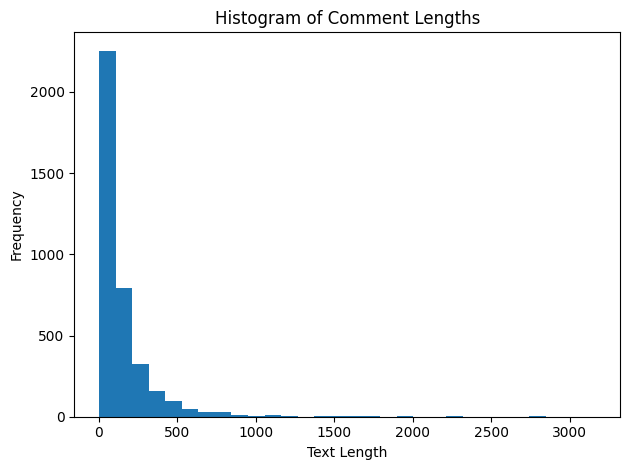

 Text Length Summary:
count    3781.000000
mean      146.909548
std       206.564924
min         3.000000
25%        40.000000
50%        84.000000
75%       173.000000
max      3162.000000
Name: text_length, dtype: float64


In [ ]:
#  Text Length analysis
df["text_length"] = df[TEXT_COL].astype(str).apply(len)

plt.figure()
plt.hist(df["text_length"], bins=30)
plt.title("Histogram of Comment Lengths")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(" Text Length Summary:")
print(df["text_length"].describe())

 Top 15 Most Common Words:
flu         2306
shot        1332
vaccine      617
sick         445
covid        413
vaccines     385
shots        351
getting      312
time         240
need         179
doctor       175
immune       170
body         155
virus        155
good         154
dtype: int64


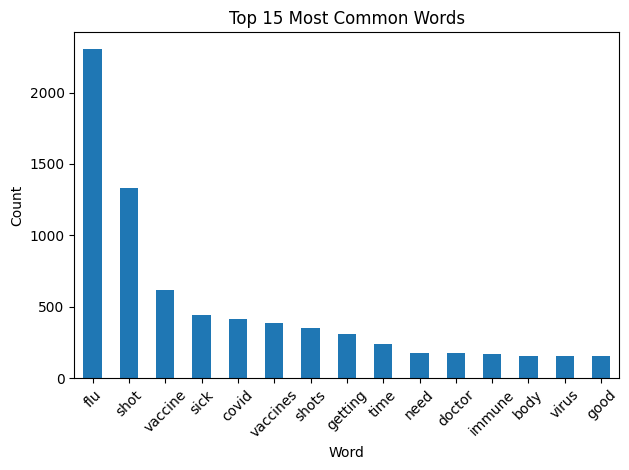

In [ ]:
#unigram
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
import pandas as pd
import matplotlib.pyplot as plt

custom_stopwords = set(ENGLISH_STOP_WORDS).union({
    "just","don","ve","people","know","like","really",
    "going","think","make","take","get","got","year",
    "years","thing","things"
})

vectorizer = CountVectorizer(
    stop_words=list(custom_stopwords), # Convert set to list
    max_features=15
)

X = vectorizer.fit_transform(df[TEXT_COL].fillna("").astype(str))

word_counts = pd.Series(
    X.sum(axis=0).A1,
    index=vectorizer.get_feature_names_out()
).sort_values(ascending=False)

print(" Top 15 Most Common Words:")
print(word_counts)

plt.figure()
word_counts.plot(kind="bar")
plt.title("Top 15 Most Common Words")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

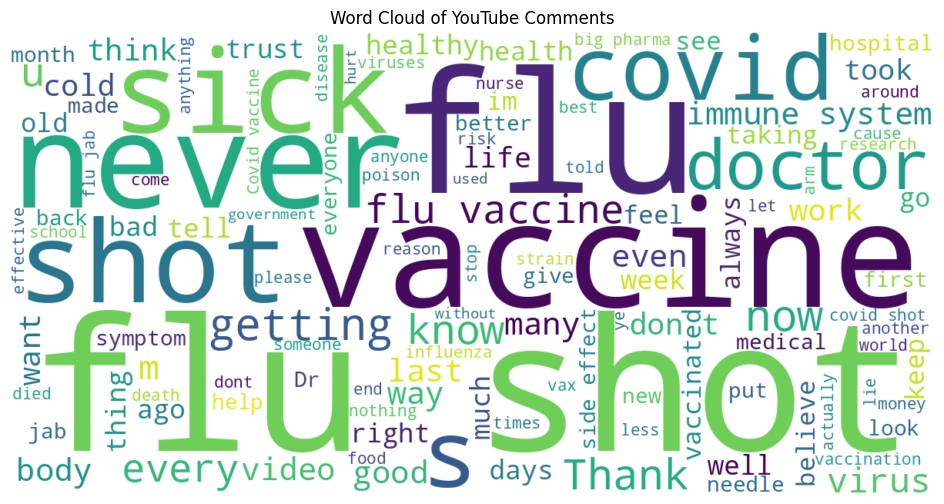

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

extra_stopwords = {
    "will","lot","time","years","year","day","one","got","make",
    "take","need","say","said","going","still","really","people"
}

stopwords = set(STOPWORDS).union(extra_stopwords)

text = " ".join(df["text_clean"].dropna().astype(str))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=stopwords,
    max_words=120,
    colormap="viridis"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of YouTube Comments")
plt.show()

Top 15 Most Common Bigrams:
flu shot         933
got flu          270
flu shots        172
flu vaccine      169
getting flu      112
years ago         71
shot year         67
big pharma        62
got sick          62
flu jab           53
shot got          52
gotten flu        43
took flu          42
covid vaccine     40
just got          38
dtype: int64


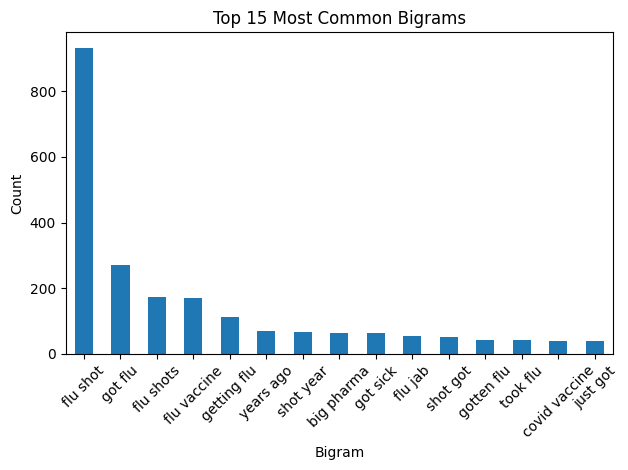

In [ ]:
#bigram

vectorizer_bigram = CountVectorizer(
    stop_words="english",
    ngram_range=(2,2),
    max_features=15
)

X_bigram = vectorizer_bigram.fit_transform(df[TEXT_COL].fillna("").astype(str))

bigram_counts = pd.Series(
    X_bigram.sum(axis=0).A1,
    index=vectorizer_bigram.get_feature_names_out()
).sort_values(ascending=False)

print("Top 15 Most Common Bigrams:")
print(bigram_counts)

plt.figure()
bigram_counts.plot(kind="bar")
plt.title("Top 15 Most Common Bigrams")
plt.xlabel("Bigram")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


 Sentiment Distribution (VADER):
sentiment
Negative    1764
Positive    1202
Neutral      815
Name: count, dtype: int64


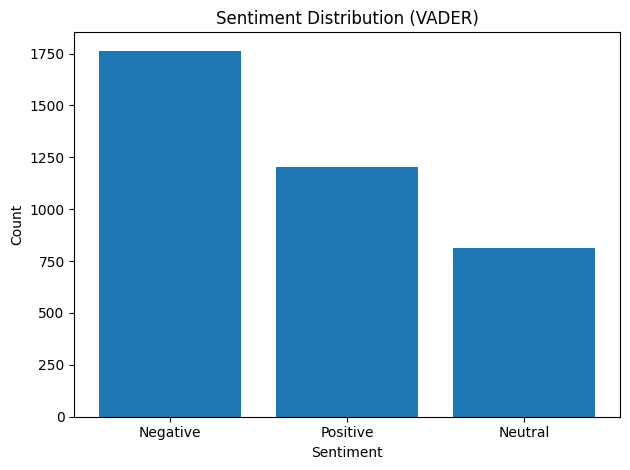

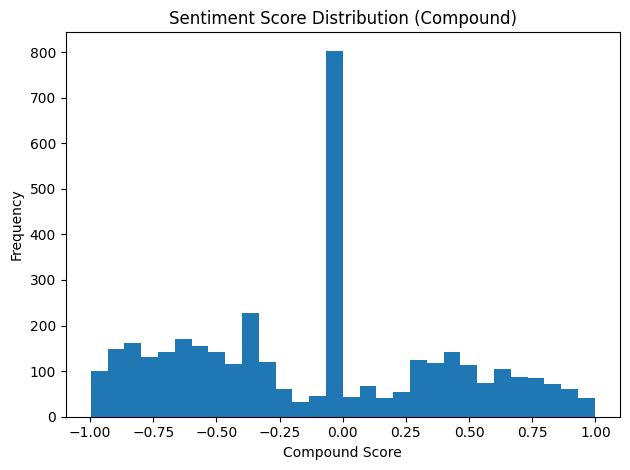

In [ ]:
# Preliminary sentiment

!pip -q install nltk

nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

df["sentiment_score"] = df[TEXT_COL].astype(str).apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

def classify_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["sentiment_score"].apply(classify_sentiment)

sent_counts = df["sentiment"].value_counts()
print(" Sentiment Distribution (VADER):")
print(sent_counts)

# Bar Chart
plt.figure()
plt.bar(sent_counts.index, sent_counts.values)
plt.title("Sentiment Distribution (VADER)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Histogram of sentiment scores
plt.figure()
plt.hist(df["sentiment_score"], bins=30)
plt.title("Sentiment Score Distribution (Compound)")
plt.xlabel("Compound Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

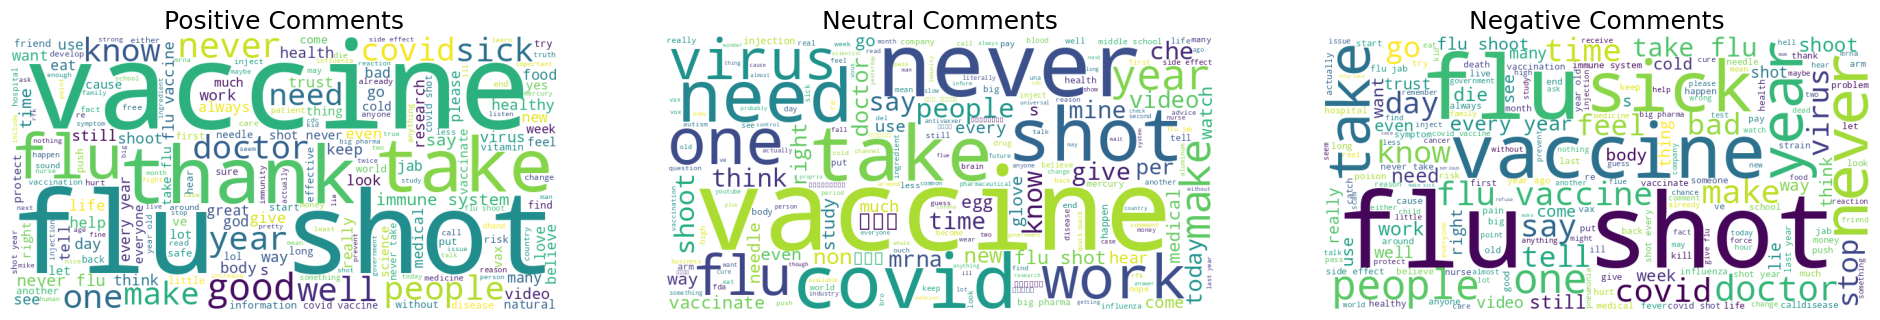

In [50]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

TEXT_COL = "text_processed"
SENT_COL = "sentiment_score"
pos_text = " ".join(df[df[SENT_COL] > 0.05][TEXT_COL].fillna("").astype(str))
neu_text = " ".join(df[(df[SENT_COL] >= -0.05) & (df[SENT_COL] <= 0.05)][TEXT_COL].fillna("").astype(str))
neg_text = " ".join(df[df[SENT_COL] < -0.05][TEXT_COL].fillna("").astype(str))

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

wc_pos = WordCloud(width=800, height=400, background_color="white").generate(pos_text)
axes[0].imshow(wc_pos); axes[0].set_title("Positive Comments", fontsize=18); axes[0].axis("off")

wc_neu = WordCloud(width=800, height=400, background_color="white").generate(neu_text)
axes[1].imshow(wc_neu); axes[1].set_title("Neutral Comments", fontsize=18); axes[1].axis("off")

wc_neg = WordCloud(width=800, height=400, background_color="white").generate(neg_text)
axes[2].imshow(wc_neg); axes[2].set_title("Negative Comments", fontsize=18); axes[2].axis("off")

plt.show()

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)

lda.fit(X)

LatentDirichletAllocation(n_components=5, random_state=42)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

custom_stopwords = [
    "just","don","ve","people","know","like","really","going",
    "think","make","take","get","got","still","thing","things"
]

# Initialize a new vectorizer for topic modeling
vectorizer_lda = CountVectorizer(
    stop_words="english",
    max_df=0.9,
    min_df=5
)

vectorizer_lda.set_params(stop_words=list(set(vectorizer_lda.get_stop_words()).union(custom_stopwords)))

# Fit transform the text data using this new vectorizer
X_lda = vectorizer_lda.fit_transform(df["text_clean"])
words_lda = vectorizer_lda.get_feature_names_out()

# Initialize and fit the LDA model using X_lda
lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)

lda.fit(X_lda)

for topic_idx, topic in enumerate(lda.components_):
    print(f"\nTopic {topic_idx+1}")
    print([words_lda[i] for i in topic.argsort()[-10:]])


Topic 1
['healthy', 'need', 'sick', 'shot', 'vaccines', 'body', 'immune', 'virus', 'vaccine', 'flu']

Topic 2
['covid', 'getting', 'years', 'time', 'im', 'thanks', 'vaccine', 'shot', 'shots', 'flu']

Topic 3
['feel', 'needle', 'arm', 'video', 'good', 'flu', 'dr', 'today', 'thank', 'shot']

Topic 4
['days', 'time', 'getting', 'covid', 'vaccine', 'years', 'sick', 'year', 'shot', 'flu']

Topic 5
['science', 'research', 'money', 'pharma', 'trust', 'medical', 'big', 'vaccine', 'covid', 'vaccines']


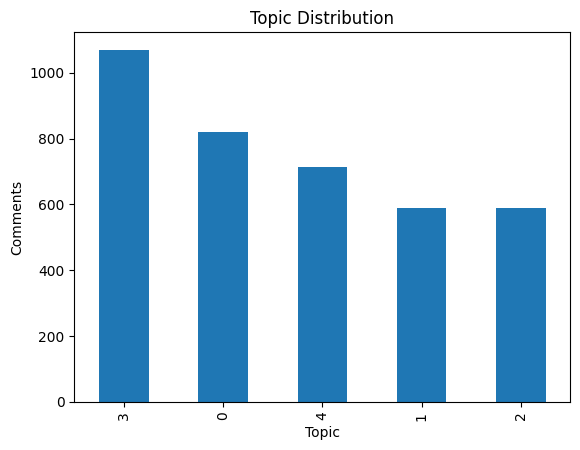

In [ ]:
topic_values = lda.transform(X)

dominant_topic = topic_values.argmax(axis=1)

import pandas as pd

topic_counts = pd.Series(dominant_topic).value_counts()

topic_counts.plot(kind="bar")
plt.title("Topic Distribution")
plt.xlabel("Topic")
plt.ylabel("Comments")
plt.show()

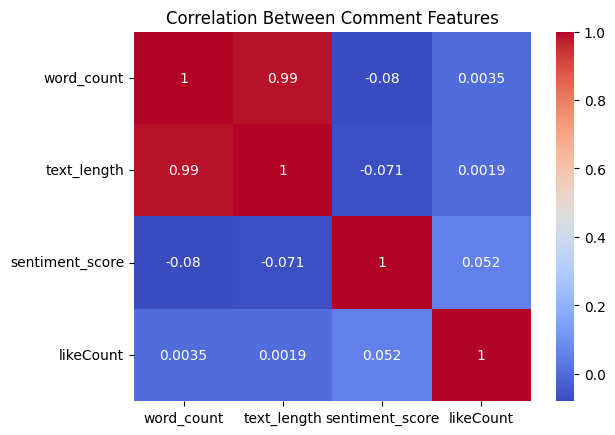

In [ ]:
features = df[["word_count","text_length","sentiment_score","likeCount"]]

corr = features.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Comment Features")
plt.show()

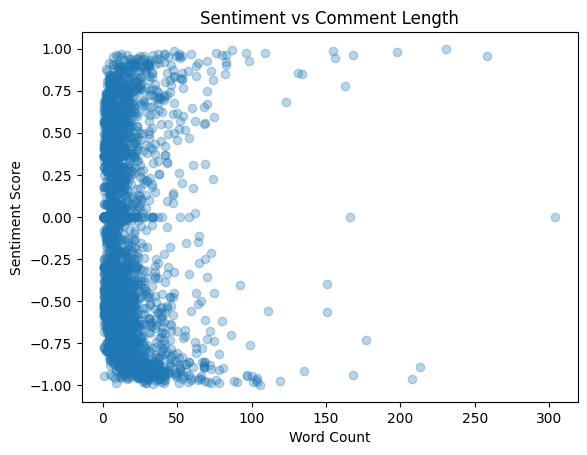

In [ ]:
plt.scatter(df["word_count"], df["sentiment_score"], alpha=0.3)
plt.xlabel("Word Count")
plt.ylabel("Sentiment Score")
plt.title("Sentiment vs Comment Length")
plt.show()